### Importing Our Functions

In [1]:
import pteams
import pbattle
import time
from IPython.display import clear_output, Image, display


### Picking Our Teams

In [15]:
num_pokemon = 2
pokedex = pteams.load_pokedex()
my_team = pteams.pick_team(num_pokemon, pokedex)
oppo_team = pteams.opponent_team(num_pokemon, pokedex)

Added charmander to your team!
Added squirtle to your team!
Your opponent chose archeops!
Your opponent chose diggersby!


### Battle

Ash's team defeated your team! Time to hit the pokegym.


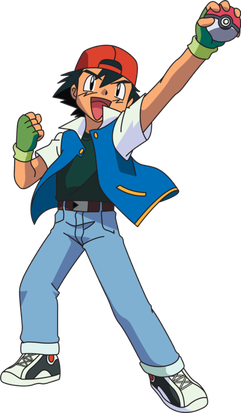

In [17]:
def pick_competitor(team:list[str], fainted:list[str]) -> str:
    for mon in team:
        if mon not in fainted:
            return mon
    return ""

def pretty_print(message:str = "", img_path:str = "") -> None:
    if message != "": print(message)
    if img_path != "": display(Image(filename=img_path))
    time.sleep(2)
    clear_output(wait=True)


# SETUP --------------------------------------------------
# lists to capture the fainted pokemon
my_fainted = []
oppo_fainted = []

# strs to capture the fighter names
my_fighter = ""
oppo_fighter = ""

# ints to capture the fighters' hp
my_hp = 0
oppo_hp = 0

# BATTLE LOOP ----------------------------------------------

while len(my_team) != len(my_fainted) and len(oppo_team) != len(oppo_fainted):
    if my_hp <= 0:
        my_fighter = pick_competitor(my_team, my_fainted)
        my_hp = pokedex[my_fighter]["hp"]
        pretty_print(f"I chose you! {my_fighter}!", f"data/images/{my_fighter}.jpg")

    if oppo_hp <= 0:
        oppo_fighter = pick_competitor(oppo_team, oppo_fainted)
        oppo_hp = pokedex[oppo_fighter]["hp"]
        pretty_print(f"Ash chose {oppo_fighter}!", f"data/images/{oppo_fighter}.jpg")


    # The main fight steps
    while True:
        oppo_hp -= pbattle.attack(my_fighter, oppo_fighter, pokedex) # our pokemon attacks opponent
        pretty_print(img_path=f"data/images/{my_fighter}.jpg")

        # if the opponents pokemon gets knocked out ....
        if oppo_hp <= 0:
            oppo_fainted.append(oppo_fighter)
            pretty_print(f"{oppo_fighter} fainted!")
            break



        my_hp -= pbattle.attack(oppo_fighter, my_fighter, pokedex) # opponent attacks us
        pretty_print(img_path=f"data/images/{oppo_fighter}.jpg")

        # if our pokemon gets knocked out ....
        if my_hp <= 0:
            my_fainted.append(my_fighter)
            pretty_print(f"{my_fighter} fainted!")
            break

# final outcome
if len(my_team) == len(my_fainted):
    print("Ash's team defeated your team! Time to hit the pokegym.")
    display(Image(filename=f"data/ash.png"))
else:
    print("You defeated Ash! You are one step closer to becoming a pokemon master!")
    display(Image(filename=f"data/thomas.png"))
    